# Multi-Modal Data Fusion - Project Work: Multi-Modal Physical Exercise Classification


In this project, real multi-modal data is studied by utilizing different techniques presented during the course. In addition, there is an optional task to try some different approaches to identify persons from the same dataset. Open MEx dataset from UCI machine learning repository is used. Idea is to apply different techniques to recognize physical exercises from wearable sensors and depth camera, user-independently.

## Author(s)
Add your information here

Name(s): Khojiakbar Botirov

Student number(s): 2214042

## Description 

The goal of this project is to develop user-independent pre-processing and classification models to recognize 7 different physical exercises measured by accelerometer (attached to subject's thigh) and depth camera (above the subject facing downwards recording an aerial view). All the exercises were performed subject lying down on the mat. Original dataset have also another acceleration sensor and pressure-sensitive mat, but those two modalities are ommited in this project. There are totally 30 subjects in the original dataset, and in this work subset of 10 person is utilized. Detailed description of the dataset and original data can be access in [MEx dataset @ UCI machine learning repository](https://archive.ics.uci.edu/ml/datasets/MEx#). We are providing the subset of dataset in Moodle.

The project work is divided on following phases:

1. Data preparation, exploration, and visualization
2. Feature extraction and unimodal fusion for classification
3. Feature extraction and feature-level fusion for multimodal classification
4. Decision-level fusion for multimodal classification
5. Bonus task: Multimodal biometric identification of persons

where 1-4 are compulsory (max. 10 points each), and 5 is optional to get bonus points (max. 5+5 points). In each phase, you should visualize and analyse the results and document the work and findings properly by text blocks and figures between the code. <b> Nice looking </b> and <b> informative </b> notebook representing your results and analysis will be part of the grading in addition to actual implementation.

The results are validated using confusion matrices and F1 scores. F1 macro score is given as 
<br>
<br>
$
\begin{equation}
F1_{macro} = \frac{1}{N} \sum_i^N F1_i,
\end{equation}
$
<br>
<br>
where $F1_i = 2  \frac{precision_i * recall_i}{precision_i + recall_i}$, and $N$ is the number of classes.
<br>

## Learning goals 

After the project work, you should  

- be able to study real world multi-modal data
- be able to apply different data fusion techniques to real-world problem
- be able to evaluate the results
- be able to analyse the outcome
- be able to document your work properly

## Relevant lectures

Lectures 1-8

## Relevant exercises

Exercises 0-6

## Relevant chapters in course book

Chapter 1-14

## Additional Material 

* Original dataset [MEx dataset @ UCI machine learning repository](https://archive.ics.uci.edu/ml/datasets/MEx#)
* Related scientific article [MEx: Multi-modal Exercises Dataset for Human Activity Recognition](https://arxiv.org/pdf/1908.08992.pdf)

# 1. Data preparation, exploration, and visualization

<a id='task1'></a>
<div class=" alert alert-warning">
    <b>Assigment.</b> <b>Task 1.</b>

Download data from the Moodle's Project section. Get yourself familiar with the folder structure and data. You can read the data files using the function given below. Each file consists one exercise type performed by single user. Data are divided on multiple folders. Note that, in each folder there is one long sequence of single exercise, except exercise 4 which is performed two times in different ways. Those two sequences belongs to same class. Do the following subtasks to pre-analyse data examples and to prepare the training and testing data for next tasks:
<br>
<br> 
<p> Read raw data from the files. Prepare and divide each data file to shorter sequences using windowing method. Similar to related article "MEx: Multi-modal Exercises Dataset for Human Activity Recognition", use 5 second window and 3 second overlapping between windows, producing several example sequences from one exercise file for classification purposes. Windowing is working so that starting from the beginning of each long exercise sequence, take 5 seconds of data points (from synchronized acceleration data and depth images) based on the time stamps. Next, move the window 2 seconds forward and take another 5 seconds of data. Then continue this until your are at the end of sequence. Each window will consists 500x3 matrix of acceleration data and 5x192 matrix of depth image data.</p>

</div>

In [183]:
# Import relevant libraries here
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd

# Enter data folder location
loc = "C:/Users/kbotirov22/OneDrive - Oulun yliopisto/PhD University  cources/Multi modal data fusion/project/MEx/MEx"

In [184]:
"""
    IMPORTANT: PLEASE DO NOT MODIFY THE CODE IN THIS CELL.
"""
def path_to_meta(p):
    meta = dict()
    meta["subject_id"] = p.parent.stem
    meta["exercise_id"] = p.stem.split("_")[-2]
    meta["trial"] = int(p.stem.split("_")[-1])
    meta["sensor_code"] = p.stem.split("_")[0]
    meta["sensor"] = {"act": "acc", "dc": "dc"}[meta["sensor_code"]]
    return meta

# Find, read, and compose the measurements
paths_record = Path(loc).glob("*/*/*.csv")
print(paths_record)
records = []

for path_record in paths_record:
    df = pd.read_csv(path_record, delimiter=",", header=None)
    meta = path_to_meta(path_record)
    
    if meta["sensor"] == "acc":
        col_names = ["time", "acc_0", "acc_1", "acc_2"]
        df.columns = col_names
    else:
        num_cols = df.shape[1]
        col_names = ["time", ] + [f"dc_{i}" for i in range(num_cols-1)]
        df.columns = col_names

    meta["df"] = df
    
    records.append(meta)

df_records = pd.DataFrame.from_records(records)

print(f"Total records found: {len(df_records)}")
print("Dataframe with all records:")
display(df_records.head())
print("Dataframe with one measurement series:")
display(df_records["df"].iloc[0].head())

<generator object Path.glob at 0x0000025B975A4CF0>
Total records found: 160
Dataframe with all records:


,subject_id,exercise_id,trial,sensor_code,sensor,df
0,01,01,1,act,acc,time acc_0 acc_1 acc_2 0 ...
1,01,02,1,act,acc,time acc_0 acc_1 acc_2 0 ...
2,01,03,1,act,acc,time acc_0 acc_1 acc_2 0 ...
3,01,04,1,act,acc,time acc_0 acc_1 acc_2 0 ...
4,01,04,2,act,acc,time acc_0 acc_1 acc_2 0 ...


Dataframe with one measurement series:


,time,acc_0,acc_1,acc_2
0,0.0,-0.515625,-0.843750,-0.131944
1,10.0,-0.515625,-0.853125,-0.134375
2,20.0,-0.515625,-0.850000,-0.140625
3,30.0,-0.515625,-0.862500,-0.150000
4,40.0,-0.525000,-0.856250,-0.156250


In [185]:
"""
    IMPORTANT: PLEASE DO NOT MODIFY THE CODE IN THIS CELL.
"""

# Extract 5-second long windows with 2-second shift (3-second overlap)

records_windowed = []

time_window = 5000.
time_offset = 2000.
    
for row_idx, row_data in df_records.iterrows():
    df_tmp = row_data["df"]
    time_start = np.min(df_tmp["time"].to_numpy())
    time_end = np.max(df_tmp["time"].to_numpy())
    
    for window_idx, t0 in enumerate(np.arange(time_start, time_end, time_offset)):
        t1 = t0 + time_window
        # Handle boundary conditions - skip the measurements from the end shorter than window size
        if t1 > time_end:
            continue
        
        tmp_data = deepcopy(row_data)
        tmp_data["window_idx"] = window_idx
        tmp_data["df"] = df_tmp[(df_tmp["time"] >= t0) &
                                (df_tmp["time"] < t1)].copy()
        
        records_windowed.append(tmp_data)
        
df_records_windowed = pd.DataFrame.from_records(records_windowed)

print(f"Total windows extracted: {len(df_records_windowed)}")
print("Dataframe with all windowed records:")
display(df_records_windowed.head())
print("Dataframe with one windowed measurement series:")
display(df_records_windowed["df"].iloc[0].head())

Total windows extracted: 4169
Dataframe with all windowed records:


,subject_id,exercise_id,trial,sensor_code,sensor,df,window_idx
0,01,01,1,act,acc,time acc_0 acc_1 acc_2 0 ...,0
1,01,01,1,act,acc,time acc_0 acc_1 acc_2 200 ...,1
2,01,01,1,act,acc,time acc_0 acc_1 acc_2 400 ...,2
3,01,01,1,act,acc,time acc_0 acc_1 acc_2 60...,3
4,01,01,1,act,acc,time acc_0 acc_1 acc_2 80...,4


Dataframe with one windowed measurement series:


,time,acc_0,acc_1,acc_2
0,0.0,-0.515625,-0.843750,-0.131944
1,10.0,-0.515625,-0.853125,-0.134375
2,20.0,-0.515625,-0.850000,-0.140625
3,30.0,-0.515625,-0.862500,-0.150000
4,40.0,-0.525000,-0.856250,-0.156250


<a id='task1'></a>
<div class=" alert alert-warning">
     
<p> <b>1.1</b> Plot few examples of prepared data for each modalities (accelometer and depth camera). Plot acceleration sensor as multi-dimensional time-series and depth camera data as 2D image. Plot 5 second acceleration sensor and depth image sequences of person 1 and 5 performing exercises 2, 5, and 6. Take the first windowed example from the long exercise sequence. </p>

</div>

In [5]:
# 1.1. Visualize selected samples for both modalities

### Your code begins here ###
import matplotlib.pyplot as plt

# Convert 'exercise_id' column to string
df_records_windowed['exercise_id'] = df_records_windowed['exercise_id'].astype(str)

# Filter data for person 1 and 5, exercises 2, 5, and 6
filtered_data = df_records_windowed[
    (df_records_windowed['subject_id'].isin(['01', '05'])) &
    (df_records_windowed['exercise_id'].isin(['02', '05', '06']))
]

# Keep only the first window per exercise
filtered_data = filtered_data.groupby(['subject_id', 'exercise_id', 'sensor']).head(1)
#display(filtered_data)

df_acc = filtered_data[filtered_data['sensor_code'] == 'act']
df_dc = filtered_data[filtered_data['sensor_code'] == 'dc']

# Merge the two DataFrames based on common columns
df_combined = pd.merge(df_acc, df_dc, on=['subject_id', 'exercise_id', 'trial', 'window_idx'], suffixes=('_acc', '_dc'))

# Display the new DataFrame
#display(df_combined)
# Plot 5-second acceleration sensor and depth image sequences for the first window per exercise
for _, row in df_combined.iterrows():
    plt.figure(figsize=(12, 6))

    # Plot accelerometer data
    plt.subplot(2, 1, 1)
    for axis in ['acc_0', 'acc_1', 'acc_2']:
        plt.plot(row['df_acc']['time'], row['df_acc'][axis], label=axis)
    plt.title(f"Accelerometer Data - Exercise {row['exercise_id']} - Person {row['subject_id']}")
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration')
    plt.legend()

    # Plot depth camera data
    plt.subplot(2, 1, 2)
    plt.imshow(row['df_dc'].iloc[:, 1:].values.T, cmap='viridis', aspect='auto')
    plt.title(f"Depth Camera Data - Exercise {row['exercise_id']} - Person {row['subject_id']}")
    plt.xlabel('Time Window')
    plt.ylabel('Depth Image Pixels')

    plt.tight_layout()
    plt.show()
    
    f = plt.figure(figsize=(16, 2))
    for i in range(5):
        df_row = row['df_dc'].iloc[i]
        title = int(df_row[0])
        df1 = df_row.drop(df_row.index[0])
        reshaped_data = np.array(df1).reshape(12, 16)
        f.add_subplot(1,5,i+1)
        plt.title(title)
        plt.imshow(reshaped_data, cmap='viridis', aspect='auto')
    plt.colorbar(label='Depth Values')
### Your code ends here ###

<a id='task1'></a>
<div class=" alert alert-warning">

<p> <b>1.2</b> Split the prepared dataset to training and testing datasets so that data of persons 1-7 are used for training and data of persons 8-10 are used for testing. In next tasks, training dataset could be further divided on (multiple) validation data folds to tune the models parameters, when needed.<br>
    
<p> Note: Training set should have 1486 windows and testing set should have 598 windows. In training set, acceleration data will have a window without a pair with depth camera data, that window should be dropped as it doesn't have a pair.<p>
  
Document your work, calculate the indicator statistics of training and testing datasets (number of examples, dimensions of each example) and visualize prepared examples.

</div>

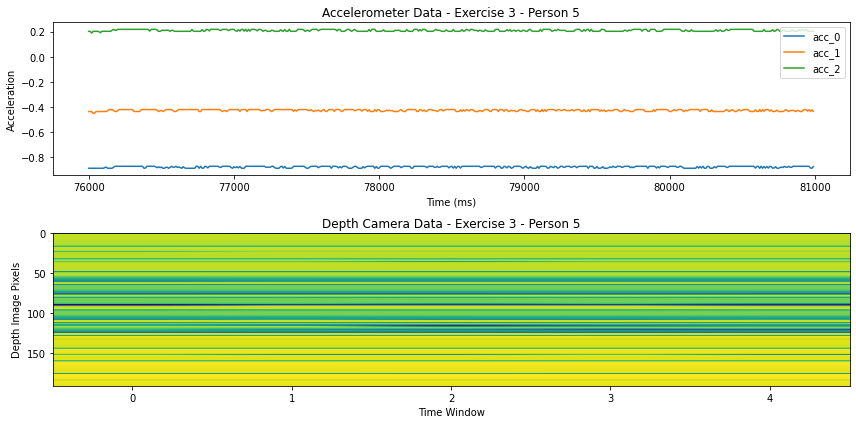

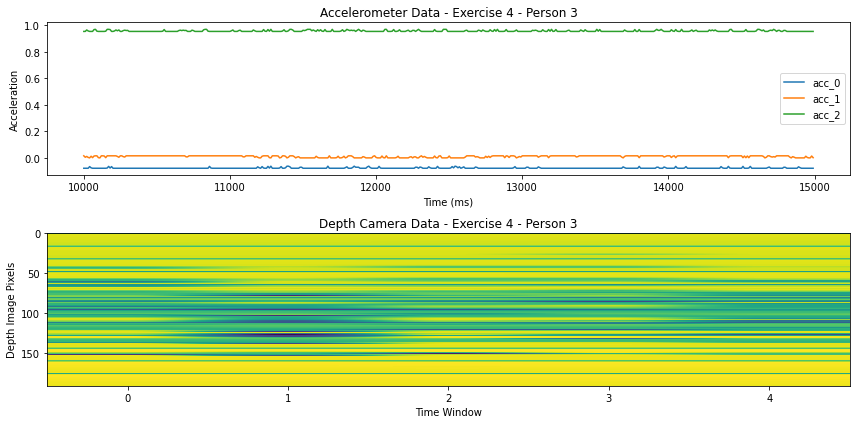

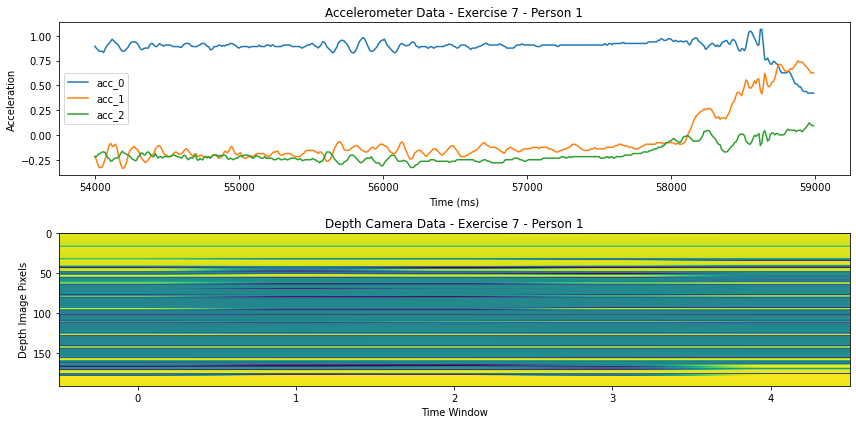

Training Dataset:
Number of examples: 1486
Dimensions of each example: 10

Testing Dataset:
Number of examples: 598
Dimensions of each example: 10


In [186]:
# 1.2. Split samples based on subject ID into training and testing datasets for futher experiments

### Your code begins here ###

# Transforming dataframe into paired dataset with paired acc and dc
df_records_windowed['subject_id'] = df_records_windowed['subject_id'].astype(int)
df_records_windowed['exercise_id'] = df_records_windowed['exercise_id'].astype(int)
df_acc = df_records_windowed[df_records_windowed['sensor_code'] == 'act']
df_dc = df_records_windowed[df_records_windowed['sensor_code'] == 'dc']
# Merge the two DataFrames based on common columns
df_paired = pd.merge(df_acc, df_dc, on=['subject_id', 'exercise_id', 'trial', 'window_idx'], suffixes=('_acc', '_dc'))

#display(df_paired)
# Split the dataset into training and testing datasets
train_subject_ids = [1, 2, 3, 4, 5, 6, 7]
test_subject_ids = [8, 9, 10]

train_data = df_paired[df_paired['subject_id'].isin(train_subject_ids)]
test_data = df_paired[df_paired['subject_id'].isin(test_subject_ids)]
#display(test_data)

# Drop windows without a pair of acceleration and depth camera data in the training set
train_data = train_data.dropna(subset=['df_acc', 'df_dc'])

# Calculate indicator statistics
train_examples, train_dimensions = train_data.shape
test_examples, test_dimensions = test_data.shape

# Visualize prepared examples
for _, row in train_data.sample(3).iterrows():
    plt.figure(figsize=(12, 6))

    # Plot accelerometer data
    plt.subplot(2, 1, 1)
    for axis in ['acc_0', 'acc_1', 'acc_2']:
        plt.plot(row['df_acc']['time'], row['df_acc'][axis], label=axis)
    plt.title(f"Accelerometer Data - Exercise {row['exercise_id']} - Person {row['subject_id']}")
    plt.xlabel('Time (ms)')
    plt.ylabel('Acceleration')
    plt.legend()

    # Plot depth camera data
    plt.subplot(2, 1, 2)
    plt.imshow(row['df_dc'].iloc[:, 1:].values.T, cmap='viridis', aspect='auto')
    plt.title(f"Depth Camera Data - Exercise {row['exercise_id']} - Person {row['subject_id']}")
    plt.xlabel('Time Window')
    plt.ylabel('Depth Image Pixels')

    plt.tight_layout()
    plt.show()

# Print indicator statistics
print("Training Dataset:")
print(f"Number of examples: {train_examples}")
print(f"Dimensions of each example: {train_dimensions}")

print("\nTesting Dataset:")
print(f"Number of examples: {test_examples}")
print(f"Dimensions of each example: {test_dimensions}")
### Your code ends here ###


# 2. Feature extraction and fusion for unimodal classification

<a id='task2'></a>
<div class=" alert alert-warning">
    <b>Assigment.</b> <b>Task 2.</b>

Use the training dataset prepared in task 1. to build models based on the combination of principal component analysis (PCA), linear discriminant analysis (LDA), and nearest neighbour (NN) classifier for each modality separately and evaluate the model on test dataset. Do the subtasks given as 
<br>
<br>
<p> <b>2.1</b> Calculate PCA and LDA transformations to reduce the dimensionality of accelerometer data (e.g., using scikit-learn implementations). Before transformations downsample data from 100 Hz to 25 Hz (using scipy.signal.resample) to get 125x3 matrix of data for each 5 sec window. You should also standardize the values to zero mean and unit variance before the transformations. Using training dataset, fit PCA with 5-dimensional subspace (i.e., choosing the 5 largest principal components) and fit LDA with 5-dimensional subspace. Transform both train and test examples to this low-dimensional feature representation. Concatenate each sequence to single vector size of 3x(5+5). Perform the fusion of PCA and LDA similar manner as presented in Lecture 3 (pages 24-25) using NN method. Evaluate the performance on testset. Show confusion matrix and F1 scores of the results. </p>

Note: Standardize the data along each axis.
<br>

Document your work, evaluate the results, and analyse the outcomes (The expected F1 score for this task should generally fall within the range of 40 to 50)
    
</div>

In [198]:
train_data['df_acc_standardized'].values

array([       time     acc_0     acc_1     acc_2
       0       0.0 -0.488823 -1.012097 -0.707853
       1      10.0 -0.488823 -1.054505 -0.712593
       2      20.0 -0.488823 -1.040369 -0.724780
       3      30.0 -0.488823 -1.096914 -0.743060
       4      40.0 -0.569971 -1.068642 -0.755247
       ..      ...       ...       ...       ...
       495  4950.0 -1.029810  0.118794  0.554843
       496  4960.0 -1.029810  0.118794  0.542656
       497  4970.0 -1.029810  0.090522  0.524376
       498  4980.0 -1.029810  0.019841  0.512189
       499  4990.0 -1.029810 -0.022568  0.481722

       [500 rows x 4 columns]                   ,
              time     acc_0     acc_1     acc_2
       0    2000.0 -0.656202 -0.842007 -0.733848
       1    2010.0 -0.603049 -0.789700 -0.733848
       2    2020.0 -0.470169 -0.821083 -0.733848
       3    2030.0 -0.443593 -0.836775 -0.717428
       4    2040.0 -0.523321 -0.824568 -0.674555
       ..      ...       ...       ...       ...
       495  6950.0

<ipython-input-200-0c4f6a34d97d>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['df_acc_standardized'] = test_data['df_acc'].apply(apply_standard_scaler)


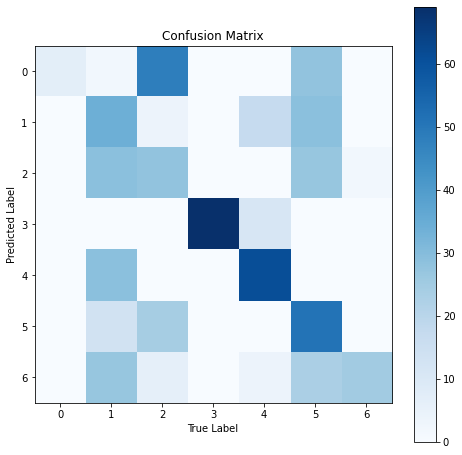


F1 Score (weighted): 0.4552445471965393


In [200]:
# 2.1

### Your code begins here ###

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score
from scipy.signal import resample

# Standardize the data
def apply_standard_scaler(df):
    # Remove column names
    df_values = df.drop(columns=['time']).values.astype(float)
    
    # Apply StandardScaler
    scaler = StandardScaler()
    df_scaled_values = scaler.fit_transform(df_values)
    
    # Create DataFrame with standardized values and original column names
    df_scaled = pd.DataFrame(df_scaled_values, columns=df.columns[1:])
    
    # Add 'time' column back
    df_scaled.insert(0, 'time', df['time'].values)
    
    return df_scaled

# Apply StandardScaler to each DataFrame in the array
train_data['df_acc_standardized'] = train_data['df_acc'].apply(apply_standard_scaler)
test_data['df_acc_standardized'] = test_data['df_acc'].apply(apply_standard_scaler)

# Function to downsample and standardize accelerometer data
def preprocess_accelerometer_data(df_accel):
    # Create a copy of the DataFrame to avoid the SettingWithCopyWarning
    df_accel = df_accel.copy()

    # Convert 'time' column to datetime type
    df_accel['time'] = pd.to_datetime(df_accel['time'], unit='ms')

    # Downsample from 100 Hz to 25 Hz
    df_accel_resampled = df_accel.resample('40L', on='time').mean().interpolate()

    return df_accel_resampled


# Function to perform PCA and LDA transformations per ACC channel
def perform_pca_lda_transformations(train_data, test_data, num_components=5):
    # Initialize empty arrays for PCA and LDA results
    X_train_pca = np.empty((1486, 0))
    X_test_pca = np.empty((598, 0))
    X_train_lda = np.empty((1486, 0))
    X_test_lda = np.empty((598, 0))
    
    # Loop through each accelerometer channel
    for acc_channel in ['acc_0', 'acc_1', 'acc_2']:
        
        # Extract accelerometer data from train and test datasets
        X_train_acc = np.stack(train_data['df_acc'].apply(lambda x: preprocess_accelerometer_data(x[["time", acc_channel]])).values)
        X_test_acc = np.stack(test_data['df_acc'].apply(lambda x: preprocess_accelerometer_data(x[["time", acc_channel]])).values)


        
        # Flatten the accelerometer data
        
        X_train_acc_flat = X_train_acc.reshape((X_train_acc.shape[0], -1))
        X_test_acc_flat = X_test_acc.reshape((X_test_acc.shape[0], -1))
        
        # Fit PCA with 5-dimensional subspace
        pca = PCA(n_components=num_components)
        X_train_pca_acc = pca.fit_transform(X_train_acc_flat)
        X_test_pca_acc = pca.transform(X_test_acc_flat)
        
        # Fit LDA with 5-dimensional subspace
        lda = LinearDiscriminantAnalysis(n_components=num_components)
        X_train_lda_acc = lda.fit_transform(X_train_acc_flat, train_data['exercise_id'])
        X_test_lda_acc = lda.transform(X_test_acc_flat)
        
        # Concatenate results for each channel
        X_train_pca = np.concatenate((X_train_pca, X_train_pca_acc), axis=1)
        X_test_pca = np.concatenate((X_test_pca, X_test_pca_acc), axis=1)
        X_train_lda = np.concatenate((X_train_lda, X_train_lda_acc), axis=1)
        X_test_lda = np.concatenate((X_test_lda, X_test_lda_acc), axis=1)

    return X_train_pca, X_test_pca, X_train_lda, X_test_lda

# Function to perform fusion using nearest neighbor (NN) method
def perform_fusion(X_pca, X_lda, y_train, X_test_pca, X_test_lda, k_neighbors=5):
    # Concatenate each sequence to a single vector of size 3x(5+5)
    X_train_fusion = np.concatenate([X_pca, X_lda], axis=1)
    X_test_fusion = np.concatenate([X_test_pca, X_test_lda], axis=1)
    
    # Check consistency of the number of samples
    if len(X_train_fusion) != len(y_train):
        raise ValueError("Inconsistent number of samples between features and labels in the training set.")

    # Perform fusion using NN method
    knn = KNeighborsClassifier(n_neighbors=k_neighbors)
    knn.fit(X_train_fusion, y_train)
    
    # Predict on the test set
    y_pred = knn.predict(X_test_fusion)
    
    return y_pred

# Perform PCA and LDA transformations on the training and testing datasets
X_train_pca, X_test_pca, X_train_lda, X_test_lda = perform_pca_lda_transformations(train_data, test_data)


# Perform fusion using nearest neighbor (NN) method
y_pred = perform_fusion(X_train_pca, X_train_lda, train_data['exercise_id'], X_test_pca, X_test_lda)

# Evaluate the performance
conf_matrix = confusion_matrix(test_data['exercise_id'], y_pred)
f1 = f1_score(test_data['exercise_id'], y_pred, average='weighted')

# Visualize confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

# Display results
print("\nF1 Score (weighted):", f1)

### Your code ends here ###

<a id='task2'></a>
<div class=" alert alert-warning">
<p> <b>2.2</b> Use PCA and LDA transformations to reduce the dimensionality of depth images. You should also standardize the values to zero mean and unit variance before the transformations. Fit PCA and LDA for all training images (12x16, 192-dimensional in vectorized form) by choosing 5-dimensional subspace for both PCA and LDA. Transform both train and test examples to this low-dimensional feature representation. Concatenate each sequence to single vector size of 5x1x(5+5). Similar to task 2.1, do the PCA and LDA fusion using NN and evaluate the performance on testset. Show confusion matrix and F1 scores of the results. </p>

Note: Standardize the data along each axis.
<br>

Document your work, evaluate the results, and analyse the outcomes (The expected F1 score for this task should generally fall within the range of 40 to 50)
    
</div>

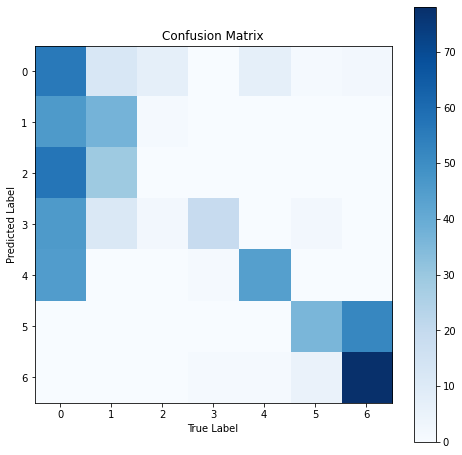

Weighted F1 Score: 0.43365918872514325


In [206]:
# 2.2

### Your code begins here ###

# Define the number of dimensions for PCA and LDA
pca_dimensions = 5
lda_dimensions = 5

# Function to concatenate PCA and LDA features
def concatenate_features(pca_features, lda_features):
    return np.concatenate([pca_features, lda_features], axis=1)

# Function to perform PCA, LDA transformations, and NN classification
def pca_lda_nn_classification(train_data, test_data, pca_dimensions, lda_dimensions):
    # Standardize data along each axis
    scaler = StandardScaler()
    train_data_std = scaler.fit_transform(train_data)
    test_data_std = scaler.transform(test_data)

    # PCA transformation
    pca = PCA(n_components=pca_dimensions)
    pca_train_features = pca.fit_transform(train_data_std)
    pca_test_features = pca.transform(test_data_std)

    # LDA transformation
    lda = LinearDiscriminantAnalysis(n_components=lda_dimensions)
    lda_train_features = lda.fit_transform(train_data_std, train_labels)
    lda_test_features = lda.transform(test_data_std)

    # Concatenate PCA and LDA features
    concatenated_train_features = concatenate_features(pca_train_features, lda_train_features)
    concatenated_test_features = concatenate_features(pca_test_features, lda_test_features)

    # Nearest Neighbor classifier
    nn_classifier = KNeighborsClassifier()
    nn_classifier.fit(concatenated_train_features, train_labels)
    predictions = nn_classifier.predict(concatenated_test_features)

    # Evaluate the performance
    cm = confusion_matrix(test_labels, predictions)
    f1 = f1_score(test_labels, predictions, average='weighted')

    return cm, f1

# Extract features and labels from the training and testing datasets
train_labels = train_data['exercise_id'].values
test_labels = test_data['exercise_id'].values

# Extract depth images from the training and testing datasets
train_depth_images = np.stack(train_data['df_dc'].apply(lambda x: x.iloc[:, 1:].values.flatten()).values)
test_depth_images = np.stack(test_data['df_dc'].apply(lambda x: x.iloc[:, 1:].values.flatten()).values)

# Perform PCA, LDA transformations, and NN classification
confusion_matrix_result, f1_score_result = pca_lda_nn_classification(
    train_depth_images, test_depth_images, pca_dimensions, lda_dimensions
)

# Visualize confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(confusion_matrix_result, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

# Print F1 score
print(f'Weighted F1 Score: {f1_score_result}')
### Your code ends here ###

# 3. Feature extraction and feature-level fusion for multimodal classification

<a id='task3'></a>
<div class=" alert alert-warning">
    <b>Assigment.</b> <b>Task 3.</b>

Prepare new feature sets for each modality and combine them to single feature representation. Compare two classifiers from scikit-learn. Train classifiers using joint feature presentation. Evaluate and compare the result using testing dataset. Do the subtasks given as 
<br>   

<p> <b>3.1</b> Similar to task 2.1, calculate PCA for accelerometer, but choose now the 10 largest principal components as 10-dim feature vector for each window. In addition, for each window calculate mean and standard deviation of each three acc channels as statistical features, resulting 6-dimensional vector. Combine these to 36-dimensional final feature vector.</p>

Document your work.
    
</div>

In [207]:
# 3.1

### Your code begins here ###

# Function to calculate statistical features (mean and std) for each window
def calculate_statistical_features(data):
    mean_features = np.mean(data, axis=1)
    std_features = np.std(data, axis=1)
    return np.concatenate([mean_features, std_features])

# Function to combine PCA and statistical features
def combine_features(pca_features, statistical_features):
    statistical_features = statistical_features.reshape(-1, 2)
    return np.concatenate([pca_features, statistical_features], axis=1)

def preprocess_accelerometer_data1(df):
    # Perform downsampling to 25 Hz using scipy.signal.resample
    resampled_data = resample(df, int(len(df) * (25 / 100)))
    return resampled_data

def perform_pca_feature_extraction(train_data, test_data, num_components=10):
    # Initialize empty arrays for PCA and LDA results
    X_train_pca_features = np.empty((1486, 0))
    X_test_pca_features = np.empty((598, 0))
    statistical_features_acc_train =  np.empty((1486, 0))
    statistical_features_acc_test = np.empty((598, 0))
    for acc_channel in ['acc_0', 'acc_1', 'acc_2']:
        # Extract accelerometer data from train and test datasets
        X_train_acc = np.stack(train_data['df_acc'].apply(lambda x: preprocess_accelerometer_data1(x[["time", acc_channel]])).values)
        X_test_acc = np.stack(test_data['df_acc'].apply(lambda x: preprocess_accelerometer_data1(x[["time", acc_channel]])).values)
     
        # Flatten the accelerometer data
        X_train_acc_flat = X_train_acc.reshape((X_train_acc.shape[0], -1))
        X_test_acc_flat = X_test_acc.reshape((X_test_acc.shape[0], -1))
    
        # Calculate PCA for accelerometer data (choose 10 largest principal components)
        pca = PCA(n_components=10)
        pca_features_acc_train = pca.fit_transform(X_train_acc_flat)
        pca_features_acc_test = pca.transform(X_test_acc_flat)
    
        # Calculate statistical features for accelerometer data
        statistical_features_acc_train = calculate_statistical_features(X_train_acc_flat)
        statistical_features_acc_test = calculate_statistical_features(X_test_acc_flat)
    
        # Combine PCA and statistical features for accelerometer data
        pca_features_acc_train_comb = combine_features(pca_features_acc_train, statistical_features_acc_train)
        pca_features_acc_test_comb = combine_features(pca_features_acc_test, statistical_features_acc_test)
    
        # Concatenate results for each channel
        X_train_pca_features = np.concatenate((X_train_pca_features, pca_features_acc_train_comb), axis=1)
        X_test_pca_features = np.concatenate((X_test_pca_features, pca_features_acc_test_comb), axis=1)


    return X_train_pca_features, X_test_pca_features

# Calculate PCA for accelerometer data (choose 10 largest principal components)
final_features_acc_train_std, final_features_acc_test_std =  perform_pca_feature_extraction(train_data, test_data)

# Display the shape of the final feature sets
print("Shape of Final Feature Set (Train):", final_features_acc_train_std.shape)
print("Shape of Final Feature Set (Test):", final_features_acc_test_std.shape)

### Your code ends here ###

Shape of Final Feature Set (Train): (1486, 36)
Shape of Final Feature Set (Test): (598, 36)


<a id='task3'></a>
<div class=" alert alert-warning">

<p> <b>3.2</b> Similar to task 2.2, calculate the PCA for depth images using same setup, but now choose the 10 largest principal components as feature vector. Concatenate the image sequence forming 50-dimensional feature vector from each windowed example.</p>

Document your work.
    
</div>

In [29]:
# 3.2

### Your code begins here ###

def perform_pca_feature_extraction_dc(train_data, test_data, num_components=10):
    # Initialize empty arrays for PCA and LDA results
    X_train_pca_features_dc = np.empty((1486, 0))
    X_test_pca_features_dc = np.empty((598, 0))
    # Extract accelerometer data from train and test datasets
    for i in range(5): 
        X_train_dc = np.stack(train_data['df_dc'].apply(lambda x: x.iloc[i, 1:].values).values)
        X_test_dc = np.stack(test_data['df_dc'].apply(lambda x: x.iloc[i, 1:].values).values)
     
        # Calculate PCA for accelerometer data (choose 10 largest principal components)
        pca = PCA(n_components=10)
        pca_features_dc_train = pca.fit_transform(X_train_dc)
        pca_features_dc_test = pca.transform(X_test_dc)
    
        # Concatenate results for each channel
        X_train_pca_features_dc = np.concatenate((X_train_pca_features_dc, pca_features_dc_train), axis=1)
        X_test_pca_features_dc = np.concatenate((X_test_pca_features_dc, pca_features_dc_test), axis=1)


    return X_train_pca_features_dc, X_test_pca_features_dc

# Calculate PCA for accelerometer data (choose 10 largest principal components)
final_features_dc_train, final_features_dc_test =  perform_pca_feature_extraction_dc(train_data, test_data)

# Display the shape of the final feature sets
print("Shape of Final Feature Set (Train):", final_features_dc_train.shape)
print("Shape of Final Feature Set (Test):", final_features_dc_test.shape)

### Your code ends here ###

Shape of Final Feature Set (Train): (1486, 50)
Shape of Final Feature Set (Test): (598, 50)


<a id='task3'></a>
<div class=" alert alert-warning">

<p> <b>3.3</b> Form a joint feature presentation of features extracted in 3.1 and 3.2, resulting 86-dimensional feature vector for each example. Normalize data between 0-1 using the training dataset. Use support vector machine (SVM) with RBF-kernel and Gaussian naiveBayes classifier (use default parameter values for both classifiers). Train the classifiers and evaluate and compare classifiers on testset using confusion matrices and F1 scores.</p>

Note: Normalize the data along each axis.
<br>

Document your work, evaluate the results, and analyse the outcomes. (The expected F1 score for this task should generally fall within the range of 55 to 70)
    
</div>

In [208]:
# 3.3

### Your code begins here ###
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Combine features from task 3.1 and task 3.2 to form an 86-dimensional feature vector
X_train_combined = np.concatenate((final_features_acc_train_std, final_features_dc_train), axis=1)
X_test_combined = np.concatenate((final_features_acc_test_std, final_features_dc_test), axis=1)

# Normalize the data between 0 and 1 using Min-Max scaling
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train_combined)
X_test_normalized = scaler.transform(X_test_combined)

# Assuming 'labels' contain the corresponding labels for your examples (0 or 1 for binary classification)
y_train = train_data['exercise_id'].values
y_test = test_data['exercise_id'].values

# Train Support Vector Machine (SVM) with RBF-kernel
svm_classifier = SVC(kernel='rbf')
svm_classifier.fit(X_train_normalized, y_train)

# Train Gaussian Naive Bayes classifier
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_normalized, y_train)

# Evaluate classifiers on the test set
y_pred_svm = svm_classifier.predict(X_test_normalized)
y_pred_nb = nb_classifier.predict(X_test_normalized)

# Calculate confusion matrices and F1 scores
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

# Calculate F1 scores for each class and the average options 'micro', 'macro', and 'weighted'
f1_score_svm_micro = f1_score(y_test, y_pred_svm, average='micro')
f1_score_svm_macro = f1_score(y_test, y_pred_svm, average='macro')
f1_score_svm_weighted = f1_score(y_test, y_pred_svm, average='weighted')

f1_score_nb_micro = f1_score(y_test, y_pred_nb, average='micro')
f1_score_nb_macro = f1_score(y_test, y_pred_nb, average='macro')
f1_score_nb_weighted = f1_score(y_test, y_pred_nb, average='weighted')

# Display results
print("Confusion Matrix for SVM:\n", conf_matrix_svm)
print("F1 Score for SVM (Micro):", f1_score_svm_micro)
print("F1 Score for SVM (Macro):", f1_score_svm_macro)
print("F1 Score for SVM (Weighted):", f1_score_svm_weighted)

print("\nConfusion Matrix for Gaussian Naive Bayes:\n", conf_matrix_nb)
print("F1 Score for Gaussian Naive Bayes (Micro):", f1_score_nb_micro)
print("F1 Score for Gaussian Naive Bayes (Macro):", f1_score_nb_macro)
print("F1 Score for Gaussian Naive Bayes (Weighted):", f1_score_nb_weighted)

Confusion Matrix for SVM:
 [[71 11  0  3  0  0  0]
 [14 70  0  0  0  0  0]
 [ 2 84  0  0  0  0  0]
 [21  0  0 59  0  0  0]
 [ 4  0  0 15 71  0  0]
 [ 0  0  0  0  0 61 27]
 [ 0  0  0  0  0  6 79]]
F1 Score for SVM (Micro): 0.6872909698996655
F1 Score for SVM (Macro): 0.647280431162329
F1 Score for SVM (Weighted): 0.6481318962758224

Confusion Matrix for Gaussian Naive Bayes:
 [[84  1  0  0  0  0  0]
 [25 59  0  0  0  0  0]
 [ 0 38 48  0  0  0  0]
 [19  4 18 39  0  0  0]
 [ 0  6  0  3 76  0  5]
 [ 0  0  0  0  0 88  0]
 [ 0  0  0  0  0  2 83]]
F1 Score for Gaussian Naive Bayes (Micro): 0.7976588628762542
F1 Score for Gaussian Naive Bayes (Macro): 0.7911718864519427
F1 Score for Gaussian Naive Bayes (Weighted): 0.7945019266376406


# 4. Decision-level fusion for multimodal classification

<a id='task4'></a>
<div class=" alert alert-warning">
    <b>Assigment.</b> <b>Task 4.</b>

Use features calculated for each modality in task 3. Choose base classifier for each modality from scikit-learn. Train classifiers for each modality feature presentations separately and combine the outputs in decision level. Evaluate and compare the result on testing dataset. Do the subtasks given as 
<br>
<br> 
<p> <b>4.1</b> Use base classifiers of support vector machine (SVM) with RBF-kernel and AdaBoost classifier (with random_state=0). 
Normalize data between 0-1 using the training dataset. Train the base classifiers by tuning the model parameters (<i>C</i> parameter and RBF-kernel <i>gamma</i> in SVM as well as <i>n_estimators</i> and <i>learning_rate</i> in Adaboost) using 10-fold cross-validation on training dataset to find optimal set of parameters (hint: use GridSearchCV from scikit-learn). For grid search use the following values $C = [0.1, 1.0, 10.0, 100.0]$, $gamma=[0.1, 0.25, 0.5, 0.75, 1.0, 2.0]$, $n\_estimators = [50, 100, 500, 1000]$, and $learning\_rate = [0.1, 0.25, 0.5, 0.75,1.0]$.<br>
Choose the best parameters and train the classifiers for each modality on whole training dataset. Is there a possibility that classifiers will overfit to training data using this parameter selection strategy? If so, why? </p>

Note: Normalize the data along each axis.
<br>

Document your work, answer the given question, evaluate the results, and analyse the outcomes.
    
</div>

In [180]:
# 4.1

### Your code begins here ###
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import make_scorer

# Assuming 'labels' contain the corresponding labels for your examples (0 or 1 for binary classification)
y_train = train_data['exercise_id'].values

# Define the parameter grids for grid search
#param_grid_svm = {'C': [0.1, 1.0, 10.0, 100.0], 'gamma': [0.1, 0.25, 0.5, 0.75, 1.0, 2.0]}
#param_grid_adaboost = {'n_estimators': [50, 100, 500, 1000], 'learning_rate': [0.1, 0.25, 0.5, 0.75, 1.0]}
#param_grid_svm = {'C': [5], 'gamma': [0.3]}
#param_grid_adaboost = {'n_estimators': [50], 'learning_rate': [0.2]}
# Function to perform grid search and return the best parameters
def perform_grid_search(classifier, param_grid, X, y):
    grid_search = GridSearchCV(classifier, param_grid, cv=10, scoring=make_scorer(f1_score, average='weighted'))
    grid_search.fit(X, y)
    return grid_search.best_params_

# Function to train the classifiers with the best parameters
def train_classifiers(X_train, y_train, best_params_svm, best_params_adaboost):
    # Normalize the data between 0 and 1 using Min-Max scaling
    scaler = MinMaxScaler()
    X_train_normalized = scaler.fit_transform(X_train)

    # Train SVM with RBF-kernel
    svm_classifier = SVC(kernel='rbf',probability=True, **best_params_svm)
    svm_classifier.fit(X_train_normalized, y_train)

    # Train AdaBoost classifier
    adaboost_classifier = AdaBoostClassifier(**best_params_adaboost)
    adaboost_classifier.fit(X_train_normalized, y_train)

    return svm_classifier, adaboost_classifier

# Assuming X_train_acc, X_train_depth are the feature sets for each modality
# Perform grid search for SVM
best_params_svm_acc = perform_grid_search(SVC(), param_grid_svm, final_features_acc_train_std, y_train)
best_params_svm_depth = perform_grid_search(SVC(), param_grid_svm, final_features_dc_train, y_train)

# Perform grid search for AdaBoost
best_params_adaboost_acc = perform_grid_search(AdaBoostClassifier(), param_grid_adaboost, final_features_acc_train_std, y_train)
best_params_adaboost_depth = perform_grid_search(AdaBoostClassifier(), param_grid_adaboost, final_features_dc_train, y_train)

# Train classifiers with the best parameters
svm_classifier_acc, adaboost_classifier_acc = train_classifiers(final_features_acc_train_std, y_train, best_params_svm_acc, best_params_adaboost_acc)
svm_classifier_depth, adaboost_classifier_depth = train_classifiers(final_features_dc_train, y_train, best_params_svm_depth, best_params_adaboost_depth)
### Your code ends here ###

<a id='task4'></a>
<div class=" alert alert-warning">


<p> <b>4.2</b> Predict probabilistic outputs of each trained classifier for both modalities using the test set. </p>
<br>
Document your work, evaluate the results, and analyse the outcomes.
    
</div>

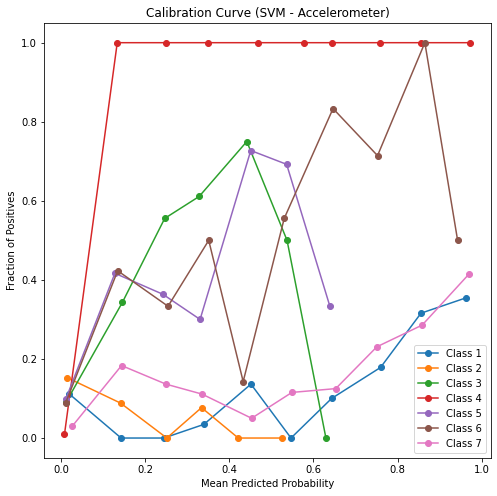

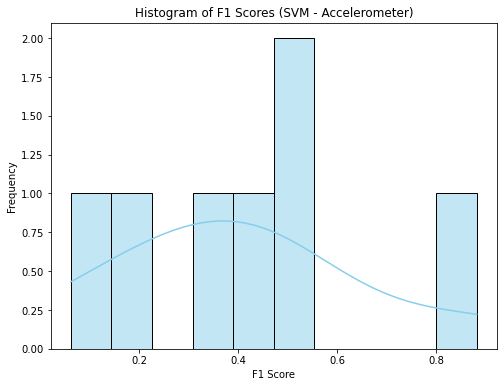

Overall F1 Score (SVM - Accelerometer): 0.4030


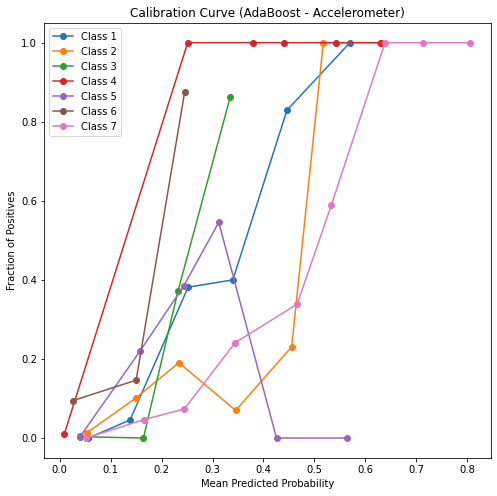

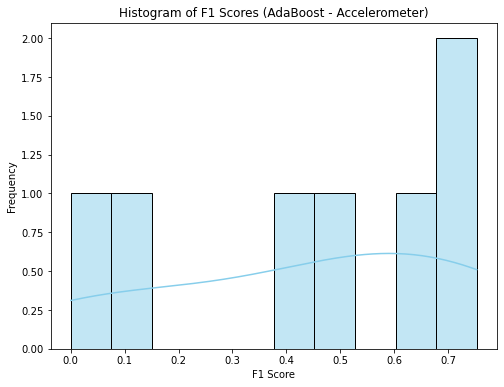

Overall F1 Score (AdaBoost - Accelerometer): 0.4318


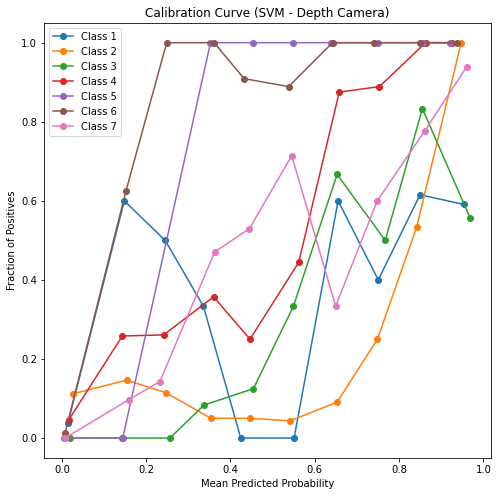

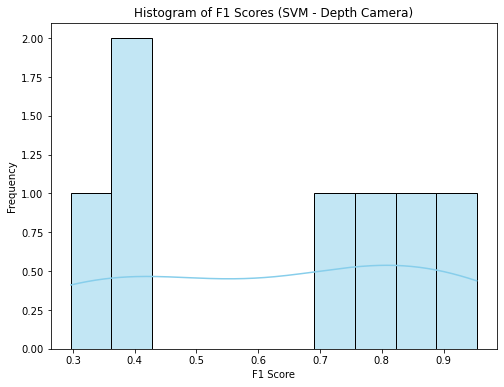

Overall F1 Score (SVM - Depth Camera): 0.6364


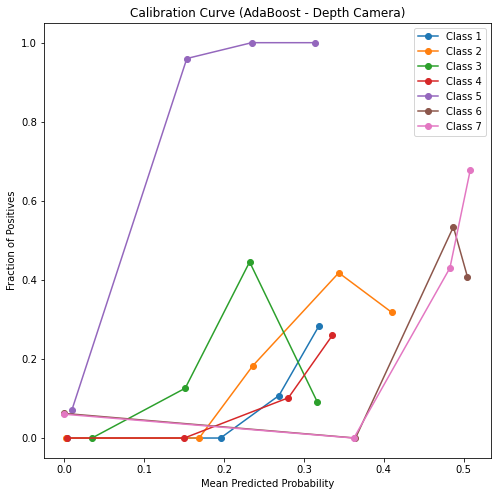

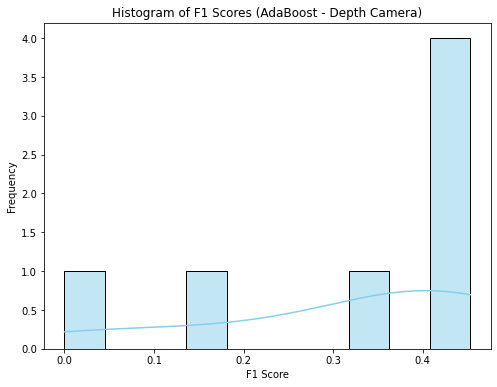

Overall F1 Score (AdaBoost - Depth Camera): 0.3118


In [181]:
# 4.2

### Your code begins here ###
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
import seaborn as sns

def plot_calibration_curve(classifier, X, y, modality_name):
    # Normalize the data between 0 and 1 using Min-Max scaling
    scaler = MinMaxScaler()
    X_normalized = scaler.fit_transform(X)
    # Binarize the labels for binary classification
    y_bin = label_binarize(y, classes=np.unique(y))
    
    # Initialize a figure
    plt.figure(figsize=(8, 8))

    # Plot calibration curves for each class
    for i in range(y_bin.shape[1]):
        prob_pos = classifier.predict_proba(X_normalized)[:, i]
        fraction_of_positives, mean_predicted_value = calibration_curve(y_bin[:, i], prob_pos, n_bins=10)
        plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'Class {i + 1}')

    # Add labels and legend
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(f'Calibration Curve ({modality_name})')
    plt.legend(loc='best')
    # Show the plot
    plt.show()
    
    # Predict the labels
    y_pred = classifier.predict(X_normalized)
    # Calculate F1 score for each class
    f1_scores = f1_score(y, y_pred, average=None)
    
    # Calculate overall F1 score
    overall_f1 = f1_score(y, y_pred, average='weighted')
    
    # Plot histogram for F1 scores
    plt.figure(figsize=(8, 6))
    sns.histplot(f1_scores, bins=10, kde=True, color='skyblue')
    plt.title(f'Histogram of F1 Scores ({modality_name})')
    plt.xlabel('F1 Score')
    plt.ylabel('Frequency')
    plt.show()

    print(f'Overall F1 Score ({modality_name}): {overall_f1:.4f}')
    
    # Show the plot
    plt.show()

# Assuming y_test contains the true labels for the test set
# Plot calibration curves for each modality
plot_calibration_curve(svm_classifier_acc, final_features_acc_test_std, y_test, 'SVM - Accelerometer')
plot_calibration_curve(adaboost_classifier_acc, final_features_acc_test_std, y_test, 'AdaBoost - Accelerometer')
plot_calibration_curve(svm_classifier_depth, final_features_dc_test, y_test, 'SVM - Depth Camera')
plot_calibration_curve(adaboost_classifier_depth, final_features_dc_test, y_test, 'AdaBoost - Depth Camera')



### Your code ends here ###

In average trainings on the accelometer readings provide more accuracy

<a id='task4'></a>
<div class=" alert alert-warning">
<p> <b>4.3</b> Combine the probabilistic outputs of different modalities by fixed classification rules: max, min, prod, and sum. Evaluate, compare, and analyse the final combined results using confusion matrices and F1 scores. Show results for each base classifier combinations (i.e., $SVM_{acc}+SVM_{depth}$, $AdaBoost_{acc}+AdaBoost_{depth}$, $SVM_{acc}+AdaBoost_{depth}$, $AdaBoost_{acc}+SVM_{depth}$)</p>
<br>
Document your work, evaluate the results, and analyse the outcomes.
    
</div>

In [182]:
# 4.3

### Your code begins here ###

# Function to combine probabilistic outputs using fixed classification rules
def combine_outputs(rule, *outputs):
    if rule == 'max':
        return np.max(outputs, axis=0)
    elif rule == 'min':
        return np.min(outputs, axis=0)
    elif rule == 'prod':
        return np.prod(outputs, axis=0)
    elif rule == 'sum':
        return np.sum(outputs, axis=0)
    else:
        raise ValueError(f"Invalid combination rule: {rule}")

# Function to evaluate and compare the combined results
def evaluate_combined_results(rule, classifier1, classifier2, X1, X2, y_true, modality_names):
    # Normalize the data between 0 and 1 using Min-Max scaling
    scaler = MinMaxScaler()
    X1_normalized = scaler.fit_transform(X1)
    X2_normalized = scaler.fit_transform(X2)

    # Predict probabilistic outputs for each modality
    prob_outputs1 = classifier1.predict_proba(X1_normalized)
    prob_outputs2 = classifier2.predict_proba(X2_normalized)

    # Combine probabilistic outputs
    combined_prob_outputs = combine_outputs(rule, prob_outputs1, prob_outputs2)

    # Assign the class with the highest probability as the final predicted label
    y_pred_combined = np.argmax(combined_prob_outputs, axis=1)
    y_pred_combined = y_pred_combined +1
    # Evaluate the combined results
    confusion_matrix_combined = confusion_matrix(y_true, y_pred_combined)
    f1_score_combined = f1_score(y_true, y_pred_combined, average='weighted')

    # Print results
    print(f'Combined Results using {rule} rule:')
    print(f'Confusion Matrix:')
    #print(confusion_matrix_combined)
    print(f'Overall F1 Score: {f1_score_combined:.4f}')

# Assuming y_test contains the true labels for the test set
# Evaluate combined results for each base classifier combination
print("Combination of SVM_acc and SVM_dc")
evaluate_combined_results('max', svm_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('min', svm_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('prod', svm_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('sum', svm_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'SVM - Depth Camera'])

print("\nCombination of AdaBoost_acc and AdaBoost_dc")
evaluate_combined_results('max', adaboost_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('min', adaboost_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('prod', adaboost_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('sum', adaboost_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'Ada Boost - Depth Camera'])

print("\nCombination of SVM_acc and AdaBoost_dc")
evaluate_combined_results('max', svm_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('min', svm_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('prod', svm_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'Ada Boost - Depth Camera'])
evaluate_combined_results('sum', svm_classifier_acc, adaboost_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['SVM - Accelerometer', 'Ada Boost - Depth Camera'])

print("\nCombination of AdaBoost_acc and SVN_dc")
evaluate_combined_results('max', adaboost_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('min', adaboost_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('prod', adaboost_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'SVM - Depth Camera'])
evaluate_combined_results('sum', adaboost_classifier_acc, svm_classifier_depth, final_features_acc_test_std, final_features_dc_test, y_test, ['Ada Boost - Accelerometer', 'SVM - Depth Camera'])
### Your code ends here ###

Combination of SVM_acc and SVM_dc
Combined Results using max rule:
Confusion Matrix:
Overall F1 Score: 0.6324
Combined Results using min rule:
Confusion Matrix:
Overall F1 Score: 0.6184
Combined Results using prod rule:
Confusion Matrix:
Overall F1 Score: 0.6110
Combined Results using sum rule:
Confusion Matrix:
Overall F1 Score: 0.6414

Combination of AdaBoost_acc and AdaBoost_dc
Combined Results using max rule:
Confusion Matrix:
Overall F1 Score: 0.4409
Combined Results using min rule:
Confusion Matrix:
Overall F1 Score: 0.4903
Combined Results using prod rule:
Confusion Matrix:
Overall F1 Score: 0.4437
Combined Results using sum rule:
Confusion Matrix:
Overall F1 Score: 0.4551

Combination of SVM_acc and AdaBoost_dc
Combined Results using max rule:
Confusion Matrix:
Overall F1 Score: 0.3601
Combined Results using min rule:
Confusion Matrix:
Overall F1 Score: 0.3649
Combined Results using prod rule:
Confusion Matrix:
Overall F1 Score: 0.3892
Combined Results using sum rule:
Confusion

# 5. Bonus task: Multimodal biometric identification of persons (optional)

<a id='task5'></a>
<div class=" alert alert-warning">
    <b>Assigment.</b> <b>Task 5.</b>

Can you build a classifier that recognizes the person who is performing the exercise? Use same 10 person dataset and split it so that first 25% of each long exercise sequence is used for training and rest 75% of each sequence is used for testing the classifier. Use same 5 second windowing with 3 seconds overlap to prepare the examples. Note that, now the person identity is the class label instead of exercise type. Max. 10 points are given but you can earn points from partial solution, as well.
<br> 
<br> 
<p> <b>5.1</b> Build a classifier to identify persons based on the features and one of the models given in task 4 (max. 5 points).</p>
<br> 
Document your work. Evaluate and compare the results using confusion matrix and F1 score.

</div>

In [ ]:
# 5.1

### Your code begins here ###

### Your code ends here ###

<a id='task5'></a>
<div class=" alert alert-warning">

<p> <b>5.2</b> Can you build your own solution (using new features, new classification model or different fusion approaches) to beat the approach in Task 5.1 ? (max. 5 points) </p>
<br>  
Document your work. Evaluate and compare the results using confusion matrix and F1 score.

</div>

In [ ]:
# 5.2

### Your code begins here ###

### Your code ends here ###